In [35]:
import pandas as pd
import numpy
import time
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, KFold, learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression

In [36]:
data_path = "fifa_world_cup_2026_player_performance.csv"

df = pd.read_csv(data_path)

df.describe()

,age,jersey_number,height_cm,weight_kg,market_value_eur,goals_team,goals_opponent,minutes_played,goals,assists,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
count,54600.000000,54600.000000,54600.000000,54600.000000,5.460000e+04,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,...,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000
mean,26.296484,13.500000,181.654341,75.754853,2.008445e+07,1.330476,1.330476,36.199817,0.055385,0.052363,...,2.850165,60.318379,46.135778,63.750396,55.572154,0.643993,0.607601,272.300311,0.030659,3.634046
std,4.067519,7.500069,6.277792,3.951481,2.718866e+07,1.147814,1.147814,36.419755,0.251900,0.239021,...,4.228436,20.234988,22.424337,19.860028,13.661343,1.093781,0.931527,116.806184,0.206520,3.163411
min,17.000000,1.000000,163.000000,65.000000,5.288220e+05,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,15.000000,5.000000,25.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,7.000000,177.000000,73.000000,4.444778e+06,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,43.700000,29.800000,46.500000,46.400000,0.000000,0.000000,184.000000,0.000000,0.000000
50%,26.000000,13.500000,182.000000,76.000000,1.027111e+07,1.000000,1.000000,24.000000,0.000000,0.000000,...,1.100000,57.000000,40.500000,61.100000,55.000000,0.000000,0.000000,268.000000,0.000000,5.400000
75%,29.000000,20.000000,186.000000,78.000000,2.342013e+07,2.000000,2.000000,75.000000,0.000000,0.000000,...,4.000000,75.100000,59.000000,78.900000,63.900000,1.000000,1.000000,359.000000,0.000000,6.400000
max,39.000000,26.000000,200.000000,87.000000,2.000000e+08,7.000000,7.000000,90.000000,4.000000,3.000000,...,37.000000,99.000000,99.000000,99.000000,99.000000,10.000000,8.000000,615.000000,4.000000,9.500000


In [37]:
# Checking missing values or null data

print(f"Missing Values : {df.isnull().sum().max()}")

Missing Values : 0


In [38]:
# Reading information about data

print("Reading the data types : \n", df.info())


<class 'pandas.DataFrame'>
RangeIndex: 54600 entries, 0 to 54599
Data columns (total 75 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player_id                 54600 non-null  str    
 1   player_name               54600 non-null  str    
 2   age                       54600 non-null  int64  
 3   nationality               54600 non-null  str    
 4   team                      54600 non-null  str    
 5   jersey_number             54600 non-null  int64  
 6   position                  54600 non-null  str    
 7   height_cm                 54600 non-null  int64  
 8   weight_kg                 54600 non-null  int64  
 9   preferred_foot            54600 non-null  str    
 10  club_name                 54600 non-null  str    
 11  market_value_eur          54600 non-null  int64  
 12  match_id                  54600 non-null  str    
 13  match_date                54600 non-null  str    
 14  stadium          

In [39]:
# Checking unique feature type object

cols = df.select_dtypes(include=['str', 'object'])

for i, col_name in enumerate(cols):
    unique_count = df[col_name].unique().sum()
    
    print(f"Index {i}: '{col_name}' has {unique_count} unique values")

Index 0: 'player_id' has P00055P00070P00066P00073P00059P00072P00058P00078P00056P00074P00069P00071P00076P00067P00057P00062P00077P00064P00061P00068P00060P00075P00063P00065P00053P00054P01225P01241P01243P01240P01228P01239P01247P01229P01244P01233P01238P01246P01226P01227P01237P01234P01235P01236P01245P01232P01248P01231P01230P01242P01224P01223P00626P00635P00650P00629P00638P00633P00636P00632P00639P00630P00642P00648P00646P00647P00634P00637P00628P00641P00631P00640P00644P00649P00643P00645P00625P00627P00133P00141P00147P00145P00140P00136P00153P00135P00154P00144P00156P00138P00137P00146P00142P00149P00134P00155P00152P00150P00148P00139P00151P00143P00131P00132P01041P01054P01059P01048P01063P01045P01062P01058P01050P01065P01066P01064P01047P01057P01056P01060P01049P01055P01061P01053P01044P01046P01051P01052P01042P01043P01017P01031P01036P01030P01023P01037P01019P01034P01038P01039P01033P01026P01020P01022P01029P01025P01021P01024P01040P01035P01032P01028P01027P01018P01016P01015P01172P01196P01193P01178P01186P01183P01

In [40]:
df.columns

Index(['player_id', 'player_name', 'age', 'nationality', 'team',
       'jersey_number', 'position', 'height_cm', 'weight_kg', 'preferred_foot',
       'club_name', 'market_value_eur', 'match_id', 'match_date', 'stadium',
       'city', 'opponent_team', 'tournament_stage', 'match_result',
       'goals_team', 'goals_opponent', 'minutes_played', 'goals', 'assists',
       'shots', 'shots_on_target', 'expected_goals_xg', 'expected_assists_xa',
       'key_passes', 'successful_passes', 'total_passes', 'pass_accuracy',
       'dribbles_attempted', 'successful_dribbles', 'crosses',
       'successful_crosses', 'tackles', 'interceptions', 'clearances',
       'blocks', 'aerial_duels_won', 'aerial_duels_lost', 'recoveries',
       'defensive_actions', 'fouls_committed', 'fouls_suffered',
       'yellow_cards', 'red_cards', 'offsides', 'saves', 'save_percentage',
       'punches', 'clean_sheet', 'goals_conceded', 'penalty_saves',
       'distance_covered_km', 'sprint_distance_km', 'top_speed_k

In [ ]:
dfe = df.copy()

drop_cols = ['player_id', 'player_name', 'match_id', 'club_name']

# Deleting Feature for preprocessing
df_clean = dfe.drop(columns=drop_cols)

dfe['tournament_stage'] = dfe['tournament_stage'].map({    
    'Group Stage': 0,
    'Round of 32': 1,
    'Round of 16': 2,
    'Quarter Finals': 3,
    'Semi Finals': 4,
    'Third Place Match': 5,
    'Final': 6
    })

object_cols = dfe.select_dtypes(include=['object', 'str']).columns.tolist()

encoder = OneHotEncoder(sparse_output=False, drop='if_binary')

encoded_array = encoder.fit_transform(dfe[object_cols])

encoded_cols = encoder.get_feature_names_out(object_cols)

encoded_df = pd.DataFrame(encoded_array, columns=encoded_cols, index=dfe.index)
dfe = dfe.drop(object_cols, axis=1).join(encoded_df)


/var/folders/kk/25nr3fln5lndmv7wmy4zdt3h0000gn/T/ipykernel_2129/3410728770.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='match_result',


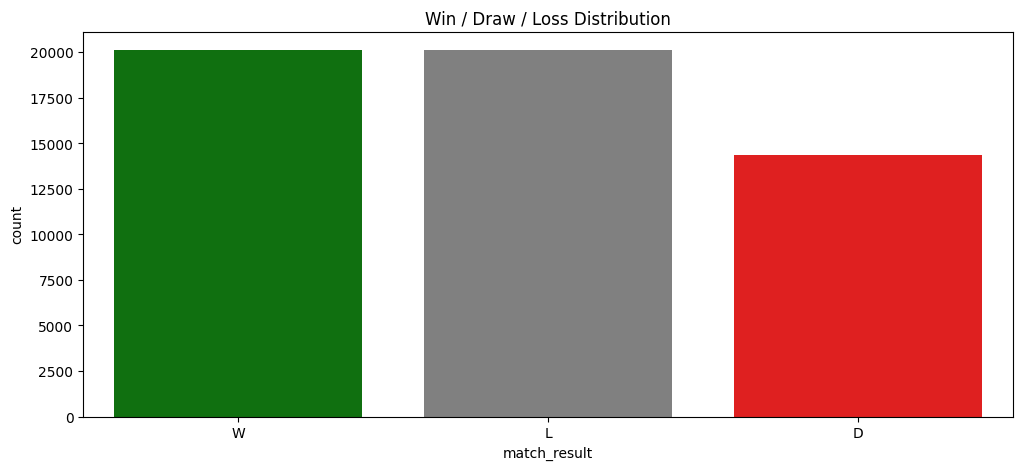

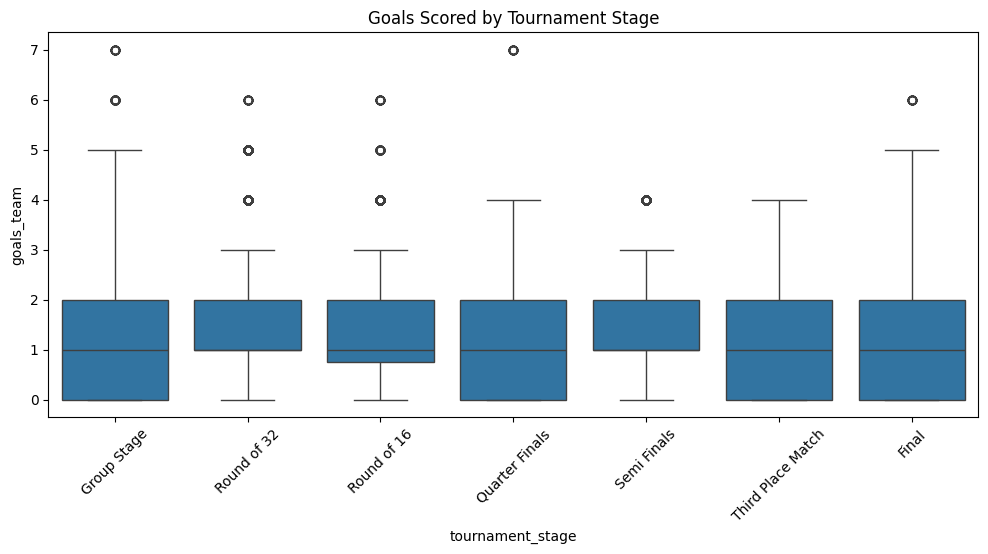

/var/folders/kk/25nr3fln5lndmv7wmy4zdt3h0000gn/T/ipykernel_2129/3410728770.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='position', y='player_rating',


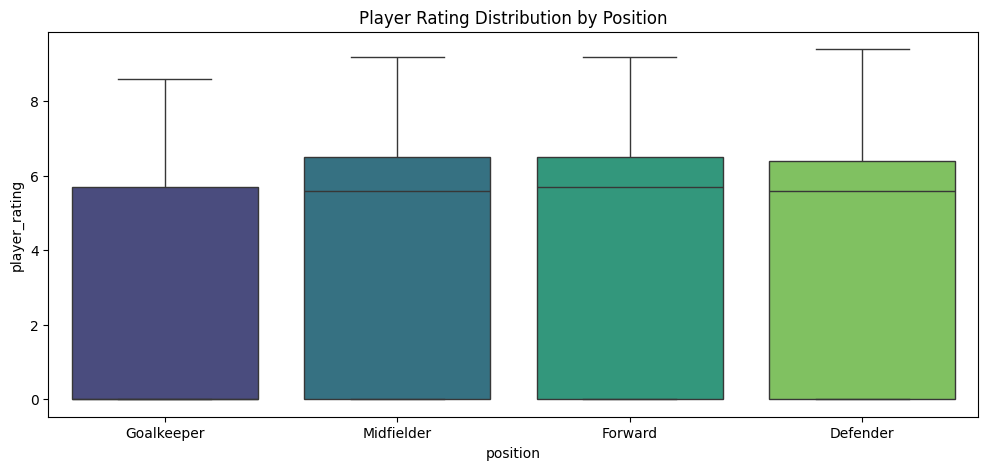

In [49]:
# EDA Showing Best Feature 


# 1. Match Result Distribution

plt.figure(figsize=(12,5))
sns.countplot(data=df, x='match_result', 
            palette=['green', 'gray', 'red'], legend=False)
plt.title('Win / Draw / Loss Distribution')

plt.show()

# 2. Goals by Tournament Stage

plt.figure(figsize=(12,5))
sns.boxplot(data=df, x='tournament_stage', y='goals_team')
plt.xticks(rotation=45)
plt.title('Goals Scored by Tournament Stage')

plt.show()

# 3. Player Rating by Position

plt.figure(figsize=(12,5))
sns.boxplot(data=df, x='position', y='player_rating',
            palette='viridis')
plt.title('Player Rating Distribution by Position')

plt.show()
